### Optimization of Helmholtz resonators for maximum sound absorption

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
import matplotlib.colors as colors



In [2]:
# Input parameters

# Environmental conditions
temp = 22  # Temperature in Celsius
p0 = 101325 # Pressure in Pa

c0 = 20.047 * (temp + 273.15) ** 0.5   # Speed of sound in m/s
rho0 = 1.29 * p0 / 101325 * 273.15 / (273.15 + temp)  # Density of air in kg/m^3
z0 = rho0 * c0  # Characteristic impedance of air in Pa*s/m
gamma = 1.4  # Adiabatic index for air
eta = 1.84e-5  # Dynamic viscosity of air in Pa*s
nu = eta / rho0  # Kinematic viscosity of air in m^2/s
tc_air = 0.0257 *(1 + 0.0034 * (temp - 20))  # Thermal conductivity of air in W/(m*K)
cp_air = 1005 + 0.1*(temp + 273.15) # Specific heat capacity of air at constant pressure in J/(kg*K)
Pr = cp_air * eta / tc_air  # Prandtl number for air
k0_air = gamma * p0  # Bulk modulus of air in Pa

# RESONATOR PARAMETERS
# Neck
rn = 1.9e-3  # Neck radius in m
ln = 10e-3  # Neck length in m
sn = np.pi * rn**2  # Cross-sectional area of the neck in m^2
vn = sn * ln  # Volume of the neck in m^3
# Cavity
rc = 10e-3  # Cavity radius in m  
lc = 25e-3  # Cavity length in m
sc = np.pi * rc**2  # Cross-sectional area of the cavity in m^2
vc = sc * lc  # Volume of the cavity in m^3

# Analysis parameters
fmin = 50 # Minimum frequency for analysis in Hz
fmax = 5000 # Maximum frequency for analysis in Hz
freqs = np.linspace(fmin, fmax, 1000)  # Frequency range for analysis in Hz
omega = 2 * np.pi * freqs  # Angular frequency range in rad/s
k0 = omega / c0  # Wavenumber in air in rad/m
r_tube = 22.5e-3  # Radius of the tube in m
stube = np.pi * r_tube**2  # Cross-sectional area of the tube in m^2

f_res = (c0 / (2 * np.pi)) * np.sqrt(sn / (ln * vc))  # Resonance frequency of the Helmholtz resonator in Hz
print(f"Resonance frequency: {f_res:.2f} Hz")




Resonance frequency: 658.68 Hz


In [3]:
rho0

1.1938455022869727

In [4]:
# def rho_eff_cyl(omega, eta, rho0, rtube):
#     G_rho = np.sqrt((1j*omega*rho0)/eta)
#     rho_eff = rho0 * (1 - (2*jv(1,rtube*G_rho))/(rtube*G_rho*jv(0,rtube*G_rho)))**(-1)
#     return rho_eff

# def K_eff_cyl(omega, eta, rho0, gamma, p0, Pr, rtube):
#     G_k = np.sqrt((1j*omega*Pr*rho0)/eta)
#     K_eff = gamma*p0 * (1 + (gamma - 1)*(2*jv(1, rtube*G_k))/(rtube*G_k*jv(0, rtube*G_k)))**(-1)
#     return K_eff


def bessel_ratio_safe(z):
    """Calculates 2*J1(z) / (z*J0(z)) safely to avoid float64 overflow."""
    # jv(z) overflows when Im(z) is large. 
    # For G_rho = sqrt(1j...), Im(z) is positive.
    mask = np.abs(np.imag(z)) < 500
    result = np.zeros_like(z, dtype=complex)
    
    # Branch 1: Numerical Bessel (Small/Medium arguments)
    if np.any(mask):
        m = mask
        result[m] = (2 * jv(1, z[m])) / (z[m] * jv(0, z[m]))
    
    # Branch 2: Asymptotic Limit (Large arguments)
    # For Im(z) > 0, the ratio 2*J1/(z*J0) converges to -2j/z
    if np.any(~mask):
        m = ~mask
        result[m] = 2j / z[m]
        
    return result

def rho_eff_cyl(omega, eta, rho0, rtube):    
    # Using +1j for e^{jwt}
    
    # G_rho = np.sqrt((-1j * omega * rho0) / eta)
    # Use the explicit (1-j) form which forces the correct quadrant
    G_rho = (1 - 1j) * np.sqrt((omega * rho0) / (2 * eta))  # Explicit form to ensure correct quadrant
    
    z = rtube * G_rho
    # rho_eff = rho0 / (1 - ratio)
    ratio = bessel_ratio_safe(z)
    return rho0 / (1 - ratio)

def K_eff_cyl(omega, eta, rho0, p0, gamma, Pr, rtube):
    # Using +1j for e^{jwt}
    # G_k = np.sqrt((1j * omega * Pr * rho0) / eta)
    G_k = (1 - 1j) * np.sqrt((omega * Pr * rho0) / (2 * eta))  # Explicit form to ensure correct quadrant
    z = rtube * G_k
    # K_eff = (gamma * p0) / (1 + (gamma - 1) * ratio)
    ratio = bessel_ratio_safe(z)
    K_adiabatic = gamma * p0
    return K_adiabatic / (1 + (gamma - 1) * ratio)

def impedance_HR(k_eff_neck, k_eff_cavity, zc_prime, zn_prime, ln_eff, lc):
    z_HR = -1j*zn_prime* ((zc_prime/zn_prime - np.tan(k_eff_neck * ln_eff)*np.tan(k_eff_cavity * lc)) / (zc_prime/zn_prime * np.tan(k_eff_neck * ln_eff) + np.tan(k_eff_cavity * lc)))
    return z_HR



\begin{array}{|l|c|c|c|l|}
\hline
\mathbf{Property} & \mathbf{Symbol} & \mathbf{Real\ Part} & \mathbf{Imaginary\ Part} & \mathbf{Physical\ Meaning\ of\ Imag\ Part} \\ \hline
\text{Bulk Modulus} & K_{eff} & > 0 & < 0 & \text{Thermal losses (heat exchange with walls)} \\ \hline
\text{Mass Density} & \rho_{eff} & > 0 & < 0 & \text{Viscous losses (friction with walls)} \\ \hline
\text{Wavenumber} & k_{eff} & > 0 & < 0 & \text{Spatial decay (attenuation as wave travels)} \\ \hline
\text{Char. Impedance} & Z_{eff} & > 0 & < 0 & \text{Phase lag (Phase lag between pressure and velocity)} \\ \hline
\end{array}

In [5]:


# Neck effective properties
rho_eff_neck = rho_eff_cyl(omega=omega, eta=eta, rho0=rho0, rtube=rn)
K_eff_neck = K_eff_cyl(omega=omega, eta=eta, rho0=rho0, p0=p0, gamma=gamma, Pr=Pr, rtube=rn)

z_eff_neck = np.sqrt(rho_eff_neck * K_eff_neck)  # Effective impedance of the neck in Pa*s/m 
# z_eff_neck = np.real(z_eff_neck) - 1j * np.abs(np.imag(z_eff_neck))  # Ensure correct sign of imaginary part
# z_eff_neck = np.abs(z_eff_neck) * np.exp(1j * np.unwrap(np.angle(z_eff_neck), period=np.pi/20, discont=0.001))  # Ensure correct sign of imaginary part

k_eff_neck = omega * np.sqrt(rho_eff_neck / K_eff_neck)  # Effective wavenumber in the neck in rad/m
# k_eff_neck = np.real(k_eff_neck) - 1j * np.abs(np.imag(k_eff_neck))
# k_eff_neck = np.abs(k_eff_neck) * np.exp(1j * np.unwrap(np.angle(k_eff_neck), period=np.pi/20, discont=0.0001))  # Ensure correct sign of imaginary part

zn_prime = z_eff_neck / sn # Normalized

# cavity effective properties
rho_eff_cavity = rho_eff_cyl(omega=omega, eta=eta, rho0=rho0, rtube=rc)
K_eff_cavity = K_eff_cyl(omega=omega, eta=eta, rho0=rho0, p0=p0, gamma=gamma, Pr=Pr, rtube=rc)

z_eff_cavity = np.sqrt(rho_eff_cavity * K_eff_cavity)  # Effective impedance of the cavity in Pa*s/m 
# z_eff_cavity = np.real(z_eff_cavity) - 1j * np.abs(np.imag(z_eff_cavity))
# z_eff_cavity = np.abs(z_eff_cavity) * np.exp(1j * np.unwrap(np.angle(z_eff_cavity), period=np.pi/20, discont=0.001))  # Ensure correct sign of imaginary part

k_eff_cavity = omega * np.sqrt(rho_eff_cavity / K_eff_cavity)  # Effective wavenumber in the cavity in rad/m
# k_eff_cavity = np.real(k_eff_cavity) - 1j * np.abs(np.imag(k_eff_cavity))
# k_eff_cavity = np.abs(k_eff_cavity) * np.exp(1j * np.unwrap(np.angle(k_eff_cavity), period=np.pi/20, discont=0.0001))  # Ensure correct sign of imaginary part

zc_prime = z_eff_cavity / sc # Normalized


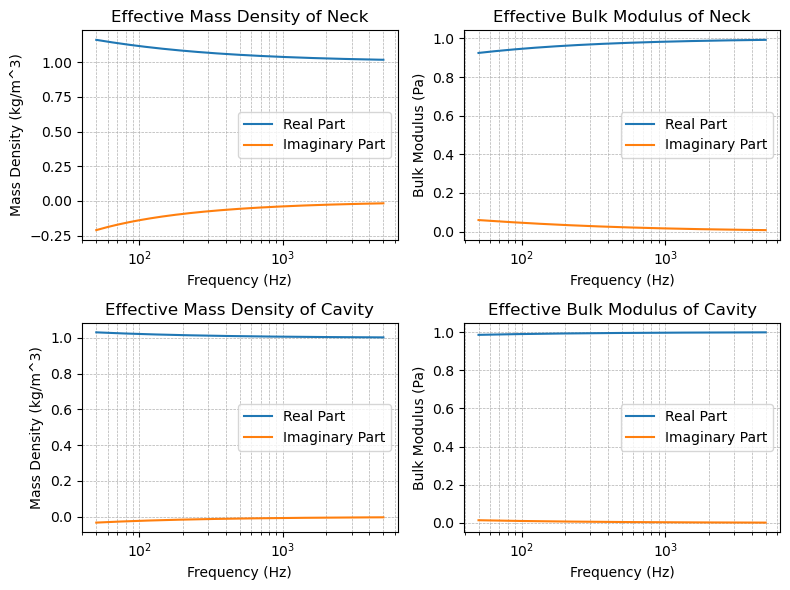

In [6]:
# Plotting mass density and bulk modulus for neck and cavity

fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs = axs.flatten()

axs[0].plot(freqs, np.real(rho_eff_neck/rho0), label='Real Part')
axs[0].plot(freqs, np.imag(rho_eff_neck/rho0), label='Imaginary Part')
axs[0].set_title('Effective Mass Density of Neck')      
axs[0].set_xlabel('Frequency (Hz)')
# axs[0].set_ylim(0.9, 1.1)  # Adjust y-axis limits for better visualization
axs[0].set_ylabel('Mass Density (kg/m^3)')
axs[0].legend()
axs[0].grid(True, which='both', ls='--', lw=0.5)
axs[0].set_xscale('log')
 
axs[1].plot(freqs, np.real(K_eff_neck/k0_air), label='Real Part')
axs[1].plot(freqs, np.imag(K_eff_neck/k0_air), label='Imaginary Part')
axs[1].set_title('Effective Bulk Modulus of Neck')  
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Bulk Modulus (Pa)')
axs[1].legend()
axs[1].set_xscale('log')
axs[1].grid(True, which='both', ls='--', lw=0.5)

axs[2].plot(freqs, np.real(rho_eff_cavity/rho0), label='Real Part')
axs[2].plot(freqs, np.imag(rho_eff_cavity/rho0), label='Imaginary Part')
axs[2].set_title('Effective Mass Density of Cavity')    
axs[2].set_xlabel('Frequency (Hz)')
axs[2].set_ylabel('Mass Density (kg/m^3)')
# axs[2].set_ylim(0.9, 1.1)  # Adjust y-axis limits for better visualization
axs[2].legend() 
axs[2].set_xscale('log')
axs[2].grid(True, which='both', ls='--', lw=0.5)


axs[3].plot(freqs, np.real(K_eff_cavity/k0_air), label='Real Part')
axs[3].plot(freqs, np.imag(K_eff_cavity/k0_air), label='Imaginary Part')
axs[3].set_title('Effective Bulk Modulus of Cavity')        
axs[3].set_xlabel('Frequency (Hz)')
axs[3].set_ylabel('Bulk Modulus (Pa)')  
axs[3].legend()
axs[3].set_xscale('log')
axs[3].grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()  
plt.show()    

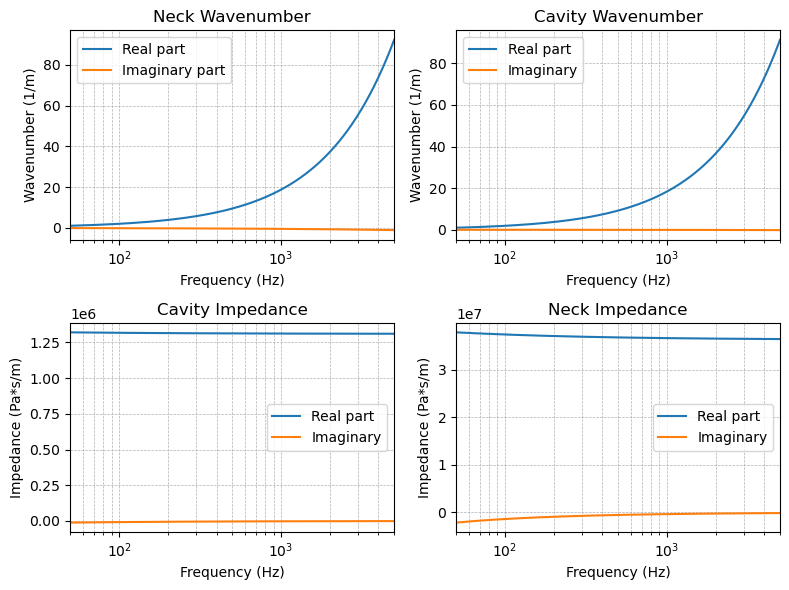

In [7]:
# Plotting the effective impedance of the neck and cavity

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
ax = ax.flatten()  # Flatten the 2D array of axes for easier indexing

ax[0].plot(freqs, np.real(k_eff_neck), label='Real part')
# ax[0].plot(freqs, np.real(k0), label='Imaginary part')
ax[0].plot(freqs, np.imag(k_eff_neck), label='Imaginary part')
ax[0].set_title('Neck Wavenumber')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Wavenumber (1/m)')
ax[0].set_xlim(fmin, fmax)
# ax[0].set_ylim(-2, 2)  # Adjust y-axis limits for better visualization
ax[0].set_xscale('log')
ax[0].grid(True, which='both', ls='--', lw=0.5)
ax[0].legend()

ax[1].plot(freqs, np.real(k_eff_cavity), label='Real part')
ax[1].plot(freqs, np.imag(k_eff_cavity), label='Imaginary')
ax[1].set_title('Cavity Wavenumber')    
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Wavenumber (1/m)')
# ax[1].set_ylim(-2, 2)  # Adjust y-axis limits for better visualization
ax[1].set_xlim(fmin, fmax)
ax[1].set_xscale('log')
ax[1].grid(True, which='both', ls='--', lw=0.5)
ax[1].legend()

ax[2].plot(freqs, np.real(zc_prime), label='Real part')
ax[2].plot(freqs, np.imag(zc_prime), label='Imaginary')
ax[2].set_title('Cavity Impedance')
ax[2].set_xlabel('Frequency (Hz)')  
ax[2].set_ylabel('Impedance (Pa*s/m)')
ax[2].set_xlim(fmin, fmax)
ax[2].set_xscale('log')
ax[2].grid(True, which='both', ls='--', lw=0.5)
ax[2].legend()

ax[3].plot(freqs, np.real(zn_prime), label='Real part')
ax[3].plot(freqs, np.imag(zn_prime), label='Imaginary')
ax[3].set_title('Neck Impedance')
ax[3].set_xlabel('Frequency (Hz)')  
ax[3].set_ylabel('Impedance (Pa*s/m)')
ax[3].set_xlim(fmin, fmax)
ax[3].set_xscale('log')
ax[3].grid(True, which='both', ls='--', lw=0.5)
ax[3].legend()

plt.tight_layout()
plt.show()

Maximum absorption of 1.00 occurs at 560.36 Hz


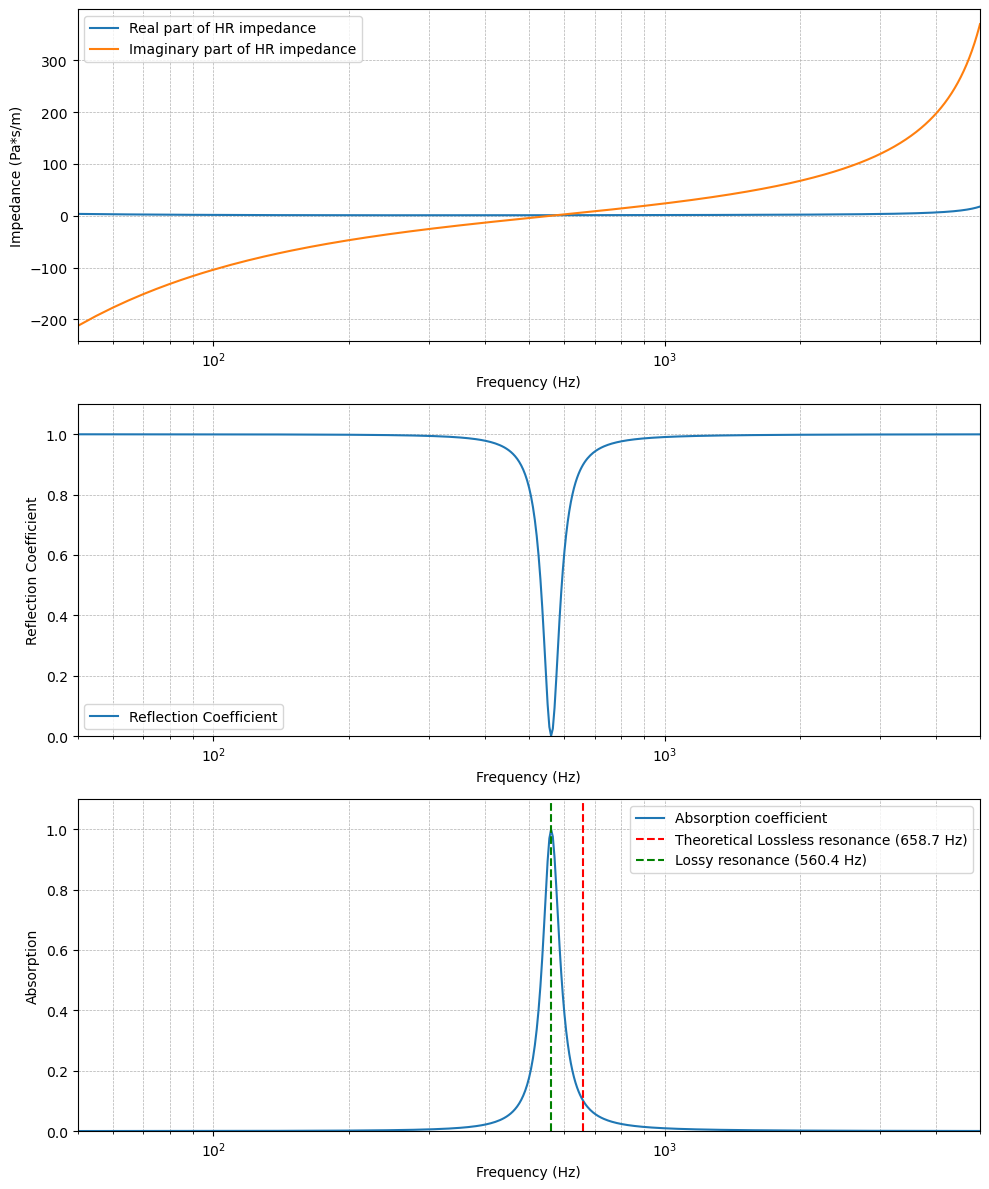

In [8]:
# 1. Cavity impedance (Rigidly backed duct)
# Using k_eff_cavity and zc_prime from your previous steps
z_cav = -1j * zc_prime * (1 / np.tan(k_eff_cavity * lc))

# 2. Total HR Impedance (Translating z_cav through the neck)
# ln_eff should include the end correction (delta)
delta1 = 0.85 * rn  # End correction for a flanged neck
delta2 = 0.6 * rn  # Additional end correction for the cavity side (unflanged)
ln_eff = ln + delta1 + delta2  # Standard correction for a flanged neck

num = z_cav + 1j * zn_prime * np.tan(k_eff_neck * ln_eff)
den = zn_prime + 1j * z_cav * np.tan(k_eff_neck * ln_eff)
z_HR = zn_prime * (num / den)

# Use this version - note the signs and the 1j at the front
# z_HR = 1j * zn_prime * ((zc_prime/zn_prime - np.tan(k_eff_neck * ln_eff) * np.tan(k_eff_cavity * lc)) / 
#                         (zc_prime/zn_prime * np.tan(k_eff_neck * ln_eff) + np.tan(k_eff_cavity * lc)))

z_HR = -1j*zn_prime* ((zc_prime/zn_prime - np.tan(k_eff_neck * ln_eff)*np.tan(k_eff_cavity * lc)) / (zc_prime/zn_prime * np.tan(k_eff_neck * ln_eff) + np.tan(k_eff_cavity * lc)))   # Not counting end correction, but it is included in ln_eff

# 3. Calculate Absorption (if HR is at the end of a tube)
R = (z_HR- (z0/stube)) / (z_HR + (z0/stube))
absorption = 1 - np.abs(R)**2

# Plotting the results
fig, ax = plt.subplots(3, 1, figsize=(10, 12))
ax[0].plot(freqs, np.real(z_HR/(z0/stube)), label='Real part of HR impedance')
ax[0].plot(freqs, np.imag(z_HR/(z0/stube)), label='Imaginary part of HR impedance')
ax[0].set_xlabel('Frequency (Hz)')  
ax[0].set_ylabel('Impedance (Pa*s/m)')
ax[0].set_xlim(fmin, fmax)
# ax[0].set_ylim(-0.05e4, 0.05e4)  # Adjust y-axis limits for better visualization
# ax[0].set_ylim(-1e2, 1e2)  # Adjust y-axis limits for better visualization
ax[0].set_xscale('log')
ax[0].grid(True, which='both', ls='--', lw=0.5)
ax[0].legend()  

ax[1].plot(freqs, np.abs(R)**2, label='Reflection Coefficient')
ax[1].set_xlabel('Frequency (Hz)')  
ax[1].set_ylabel('Reflection Coefficient')
ax[1].set_xlim(fmin, fmax)
ax[1].set_xscale('log')
ax[1].grid(True, which='both', ls='--', lw=0.5)
ax[1].set_ylim(0, 1.1)  # Reflection coefficient should be between 0 and 1
ax[1].legend()

idx_max_absorption = np.argmax(absorption)
f_max_absorption = freqs[idx_max_absorption]
absorption_at_max = absorption[idx_max_absorption]
print(f"Maximum absorption of {absorption_at_max:.2f} occurs at {f_max_absorption:.2f} Hz") 

ax[2].plot(freqs, absorption, label='Absorption coefficient')
ax[2].axvline(f_res, color='red', linestyle='--', label=f'Theoretical Lossless resonance ({f_res:.1f} Hz)')
ax[2].axvline(f_max_absorption, color='green', linestyle='--', label=f'Lossy resonance ({f_max_absorption:.1f} Hz)')
ax[2].plot()
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('Absorption')
ax[2].set_xlim(fmin, fmax)  
ax[2].set_xscale('log')
ax[2].grid(True, which='both', ls='--', lw=0.5)
ax[2].legend()
ax[2].set_ylim(0, 1.1)  # Absorption coefficient should be between 0 and 1
plt.tight_layout()
plt.show()

### Calculus in the Complex Plane ($\hat\omega$)

Resonance frequency: 658.68 Hz
Perfect absorption zero found at: 561.12 + 0.60j Hz
Perfect reflection pole found at: 561.12 + 29.86j Hz


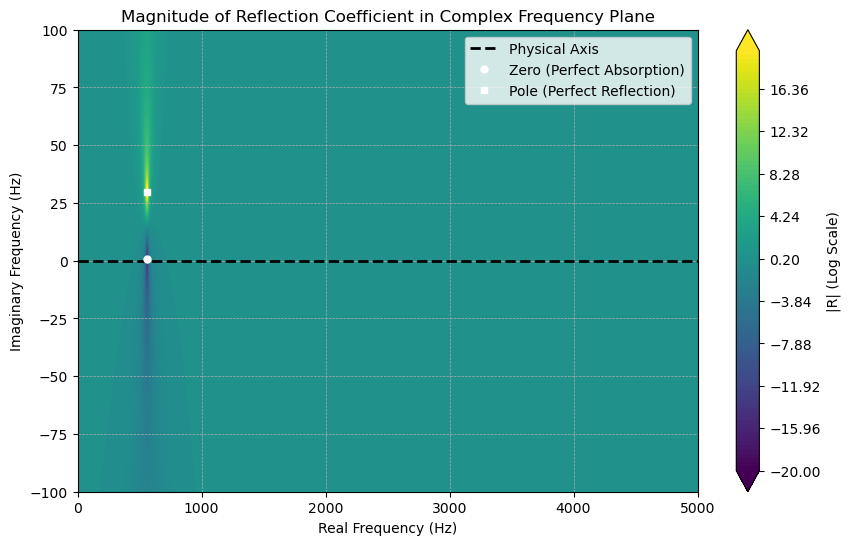

Estimated Q-factor from pole location: 9.40


In [9]:
# rn = 1.5e-3  # Neck radius in m
# rc = 15e-3  # Cavity radius in m
# lc = 20e-3  # Cavity length in m
# ln = 5e-3  # Neck length in m

# sn = np.pi * rn**2  # Cross-sectional area of the neck in m^2
# vn = sn * ln  # Volume of the neck in m^3
# sc = np.pi * rc**2  # Cross-sectional area of the cavity in m^2
# vc = sc * lc  # Volume of the cavity in m^3


f_res = (c0 / (2 * np.pi)) * np.sqrt(sn / (ln * vc))  # Resonance frequency of the Helmholtz resonator in Hz
print(f"Resonance frequency: {f_res:.2f} Hz")

# 1. Define your complex frequency grid
f_real = np.linspace(0, fmax, 500)
# sigma represents the imaginary part of frequency (damping axis)
f_imag = np.linspace(-100, 100, 500) 

F_REAL, F_IMAG = np.meshgrid(f_real, f_imag)  # Create a 2D grid of real and imaginary frequencies

# 2. This is the crucial step: Create the complex omega
# s = sigma + j*omega is standard, but for your convention:
omega_complex = 2 * np.pi * (F_REAL + 1j * F_IMAG)  # Complex angular frequency grid

# 3. Call your existing functions with the 2D array
# Numpy handles the element-wise complex math automatically
rho_n = rho_eff_cyl(omega=omega_complex, eta=eta, rho0=rho0, rtube=rn)
K_n = K_eff_cyl(omega=omega_complex, eta=eta, rho0=rho0, p0=p0, gamma=gamma, Pr=Pr, rtube=rn)
z_n = np.sqrt(rho_n * K_n) / sn  # Normalized neck impedance
k_n = omega_complex * np.sqrt(rho_n / K_n)  # Effective wavenumber in the neck

rho_c = rho_eff_cyl(omega=omega_complex, eta=eta, rho0=rho0, rtube=rc)
K_c = K_eff_cyl(omega=omega_complex, eta=eta, rho0=rho0, p0=p0, gamma=gamma, Pr=Pr, rtube=rc)
z_c = np.sqrt(rho_c * K_c) / sc  # Normalized cavity impedance
k_c = omega_complex * np.sqrt(rho_c / K_c)  # Effective wavenumber in the cavity

# 4. Calculate Z_HR and R as you did before
Z_HR_complex = impedance_HR(k_eff_neck=k_n, k_eff_cavity=k_c, zc_prime=z_c, zn_prime=z_n, ln_eff=ln_eff, lc=lc)
R_complex = (Z_HR_complex - (z0/stube)) / (Z_HR_complex + (z0/stube))

# 5. Plot the magnitude
fig, ax = plt.subplots(figsize=(10, 6))
# ax.contourf(F_REAL, F_IMAG, np.abs(R_complex), levels=50, cmap='viridis')

levels = np.linspace(-20, 20, 100)
pcm = ax.contourf(F_REAL, F_IMAG, 10 * np.log10(np.abs(R_complex)**2), 
                  levels=levels, # 50 levels from 0.001 to 1
                  extend='both', 
                  cmap='viridis')

fig.colorbar(pcm, label='|R| (Log Scale)')
ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Physical Axis')

idx = np.unravel_index(np.argmax(np.abs(R_complex)), R_complex.shape)
idx2 = np.unravel_index(np.argmin(np.abs(R_complex)), R_complex.shape)

f_pole_real = F_REAL[idx]
f_pole_imag = F_IMAG[idx]

f_zero_real = F_REAL[idx2]
f_zero_imag = F_IMAG[idx2]

print(f"Perfect absorption zero found at: {f_zero_real:.2f} + {f_zero_imag:.2f}j Hz")
print(f"Perfect reflection pole found at: {f_pole_real:.2f} + {f_pole_imag:.2f}j Hz")

# Plot a marker on the zero
ax.plot(f_zero_real, f_zero_imag, 'wo', markersize=5, label='Zero (Perfect Absorption)')
ax.plot(f_pole_real, f_pole_imag, 'ws', markersize=5, label='Pole (Perfect Reflection)')

ax.set_xlabel('Real Frequency (Hz)')
ax.set_ylabel('Imaginary Frequency (Hz)')
ax.set_title('Magnitude of Reflection Coefficient in Complex Frequency Plane')
ax.legend()
# ax.set_xlim(100, 2000)
# ax.set_xscale('log')
ax.grid(True, which='both', ls='--', lw=0.5)
plt.show()

# plt.contourf(F_REAL, F_IMAG, np.abs(R_complex), levels=5, cmap='viridis')
# plt.axhline(0, color='cyan', linestyle='--', linewidth=2, label='Physical Axis')

q_factor = np.abs(f_pole_real / (2 * f_pole_imag))
print(f"Estimated Q-factor from pole location: {q_factor:.2f}")


| Action | Effect on Pole | Effect on Q |
| --- | --- | --- |
| Increase Cavity Volume (Vcav) | Moves the pole closer to the real axis. | Increases Q (Narrower peak). |
| Decrease Neck Radius (rneck) | *Increases viscous resistance, pushing the pole deeper into the negative imaginary plane.* | Decreases Q (Broader peak). |

Maximum absorption found at: 561.12 + 0.60j Hz with alpha = 1.00


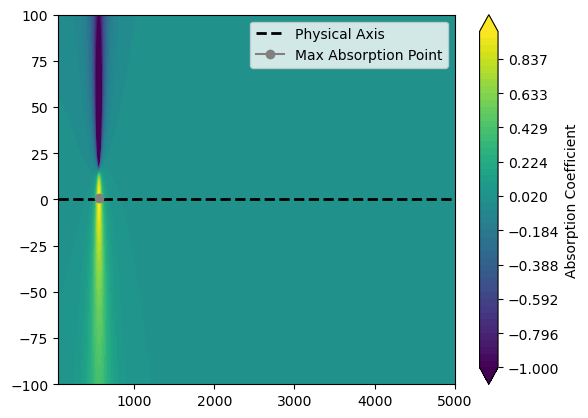

In [10]:
alpha_c = 1 - np.abs(R_complex)**2
idx_max = np.unravel_index(np.argmax((alpha_c)), alpha_c.shape)
f_abs_real = F_REAL[idx_max]
f_abs_imag = F_IMAG[idx_max]
print(f"Maximum absorption found at: {f_abs_real:.2f} + {f_abs_imag:.2f}j Hz with alpha = {alpha_c[idx_max]:.2f}") 


plt.contourf(F_REAL, F_IMAG, alpha_c, levels=np.linspace(-1,1,50), extend='both', cmap='viridis')
plt.axhline(0, color='black', linestyle='--', linewidth=2, label='Physical Axis')
plt.plot(f_abs_real, f_abs_imag, color='grey',marker='o', label='Max Absorption Point')
plt.colorbar(label='Absorption Coefficient')
plt.xlim(50, 5000)
plt.legend()
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(freqs, alpha, label='Absorption Coefficient')
# ax.set_xlabel('Frequency (Hz)')
# ax.set_ylabel('Absorption Coefficient')
# ax.set_xlim(fmin, fmax)
# ax.set_xscale('log')

In the context of complex analysis and acoustics, a pole is a point in the complex frequency plane where the function's value blows up to infinity ($|R| \to \infty$). Since we are looking at the Reflection Coefficient $R$, here is the physical and mathematical breakdown of what that means for your Helmholtz Resonator:

## 1. The Mathematical Definition
If your reflection coefficient is defined as:
\[ R(\omega) = \frac{Z_{HR}(\omega) - Z_0}{Z_{HR}(\omega) + Z_0} \]
A Zero occurs when the numerator is zero: $Z_{HR} = Z_0$. (This is Perfect Absorption).  
A Pole occurs when the denominator is zero: $Z_{HR} = -Z_0$.

## 2. The Physical Meaning of a Pole
In acoustics, a pole represents the natural resonance (eigenfrequency) of the system.  
Even if there is no external sound hitting the resonator, the system "wants" to vibrate at this complex frequency.  
Because your resonator has damping (viscous and thermal losses), the poles will always be located in the lower half of the complex plane ($f_{\text{imag}} < 0$).  
This indicates that the natural vibration will eventually die out (decay) due to friction.

## 3. Visualizing Poles vs. Zeros on your Heatmap
When you look at your contour plot:

- **The Zeros (Deep Pits):** These are the points where the color goes to the darkest/lowest values (e.g., -60 dB). These are the "Blue Holes" you are hunting for to get 100\% absorption.
- **The Poles (High Peaks):** These are the points where the function blows up. On your heatmap, these will look like "Volcanoes" where the values suddenly spike to huge positive numbers.

## 4. Why Poles Matter for Design
While you tune the Zero to hit the physical axis for perfect absorption, the Pole tells you about the "Q-factor" or the bandwidth of your resonator.  

- If the Pole is very close to the physical axis ($f_{\text{imag}} \approx 0$), the resonance is very "sharp" and narrow (high Q).
- If the Pole is pushed deep into the negative imaginary region, the resonance is "broad" and covers more frequencies, but the peak absorption might be lower.

## Troubleshooting your Heatmap
If you see a "White Hole" or an area that looks like it's glitching out with extremely high values, you have likely found a Pole.  

**Quick Tip:** If you are plotting $10 \log_{10}(|R|^2)$, a Pole will try to go to $+\infty$ dB, and a Zero will try to go to $-\infty$ dB.  
Most plotting software will "clip" the pole, making it look like a flat-topped plateau if you don't set your `vmax` high enough.  

Does your current plot show both a "pit" (Zero) and a nearby "peak" (Pole)?

<center><h2 style="font-size:44px;"> Annex </h2></center>

### Physical Interpretation of Complex Effective Parameters

#### 1. Effective Density ($\rho_{eff}$)
In a narrow tube, air isn't just a simple mass. The air layers near the wall "stick" due to viscosity.
* **Real Part (Dynamic Mass):** Represents the **Dynamic Inertia**. 
  $$\text{Re}(\rho_{eff}) = \text{Mass of air} + \text{Viscous ``added mass''}$$
  At low frequencies, the air has to "drag" the boundary layer with it, making the air appear heavier than its static density $\rho_{0}$. As frequency increases, the boundary layer thins, and $\text{Re}(\rho_{eff}) \to \rho_{0}$.
* **Imaginary Part (Viscous Loss):** Represents **Viscous Damping**. 
  This is the work done against friction. In the $e^{j\omega t}$ convention, a **negative** imaginary part indicates that the pressure must lead the velocity to overcome viscous resistance, resulting in energy dissipation.

#### 2. Effective Bulk Modulus ($K_{eff}$)
This describes the volumetric elasticity or how "squishy" the air is under pressure.
* **Real Part (Dynamic Stiffness):** Represents the **Dynamic Elasticity**. 
  This value transitions from $P_{0}$ (isothermal—heat has time to escape to the walls) at low frequencies to $\gamma P_{0}$ (adiabatic—heat is trapped) at high frequencies. It represents the actual "springiness" of the air volume.
* **Imaginary Part (Thermal Loss):** Represents **Thermal Damping**. 
  Heat is generated during compression and absorbed during expansion. Because the tube walls have a high thermal capacity, energy is lost via heat exchange. A **negative** imaginary part represents the hysteresis/lag caused by this thermal energy leak.

#### 3. Characteristic Impedance ($Z_{eff} = \sqrt{\rho_{eff} K_{eff}}$)
This is the "resistance to flow" that the medium presents to the acoustic wave.
* **Real Part (Resistance):** Represents **Acoustic Resistance**. 
  This value **must always be positive**. It represents the real power from the sound wave being converted into heat. A negative value would imply an active energy source ($Z_{active}$).
* **Imaginary Part (Reactance):** Represents **Acoustic Reactance**. 
  This indicates how the air stores energy. A positive reactance ($\text{Im}(Z) > 0$) implies the air is acting primarily as a **mass** (inertial), while a negative reactance ($\text{Im}(Z) < 0$) implies it is acting as a **spring** (compliant).

#### 4. Complex Wavenumber ($k_{eff} = \omega \sqrt{\frac{\rho_{eff}}{K_{eff}}}$)
This describes the spatial characteristics of the wave as it propagates along the $x$-axis.
* **Real Part (Phase Constant):** Represents the **Spatial Phase Rate**. 
  It determines the wavelength inside the tube $\lambda_{eff} = \frac{2\pi}{\text{Re}(k_{eff})}$. Because $\rho_{eff} > \rho_{0}$, the phase velocity $c_{eff} = \frac{\omega}{\text{Re}(k_{eff})}$ is slower than the free-field speed of sound.
* **Imaginary Part (Attenuation):** Represents the **Attenuation Constant**. 
  Since the wave propagates as $p(x) \propto e^{-j k_{eff} x}$, a **negative** imaginary part ($k_{eff} = \beta - j\alpha$) results in an exponential decay term $e^{-\alpha x}$. This mathematically describes the sound pressure decreasing as the wave travels down the tube.

---

### Summary Table

$$
\begin{array}{|l|c|l|l|}
\hline
\text{Parameter} & \text{Symbol} & \text{Real Part (Re)} & \text{Imaginary Part (Im)} \\ \hline
\text{Effective Density} & \rho_{eff} & \text{Dynamic Inertia / Added Mass} & \text{Viscous Damping (Friction)} \\ \hline
\text{Bulk Modulus} & K_{eff} & \text{Dynamic Stiffness} & \text{Thermal Damping (Heat Loss)} \\ \hline
\text{Char. Impedance} & Z_{eff} & \text{Acoustic Resistance (Loss)} & \text{Acoustic Reactance (Storage)} \\ \hline
\text{Wavenumber} & k_{eff} & \text{Phase Constant } (2\pi/\lambda) & \text{Attenuation (Spatial Decay)} \\ \hline
\end{array}
$$

### Physical Interpretation of Complex Effective Acoustic Parameters ($e^{j\omega t}$ convention)

$$
\begin{array}{|l|c|l|l|}
\hline
\text{Parameter} & \text{Symbol} & \text{Real Part (Re)} & \text{Imaginary Part (Im)} \\ \hline
\text{Effective Density} & \rho_{eff} & \begin{array}{l} \text{Dynamic Inertia:} \\ \text{Mass + viscous added mass} \end{array} & \begin{array}{l} \text{Viscous Damping:} \\ \text{Drag and energy dissipation} \end{array} \\ \hline
\text{Bulk Modulus} & K_{eff} & \begin{array}{l} \text{Dynamic Stiffness:} \\ \text{Resistance to compression} \end{array} & \begin{array}{l} \text{Thermal Damping:} \\ \text{Heat exchange with walls} \end{array} \\ \hline
\text{Impedance} & Z_{eff} & \begin{array}{l} \text{Acoustic Resistance:} \\ \text{Real power lost as heat} \end{array} & \begin{array}{l} \text{Acoustic Reactance:} \\ \text{Stored energy (Mass/Spring)} \end{array} \\ \hline
\text{Wavenumber} & k_{eff} & \begin{array}{l} \text{Phase Constant:} \\ \text{Spatial phase rate } (2\pi/\lambda) \end{array} & \begin{array}{l} \text{Attenuation:} \\ \text{Spatial amplitude decay} \end{array} \\ \hline
\end{array}
$$



### Detailed Interpretation of Complex Effective Acoustic Parameters ($e^{j\omega t}$ convention)

$$
\begin{array}{|l|c|l|l|}
\hline
\textbf{Parameter} & \textbf{Symbol} & \textbf{Real Part (Re) \& Behavior} & \textbf{Imaginary Part (Im) \& Damping} \\ \hline
\text{Effective Density} & \rho_{eff} & 
\begin{array}{l} 
\textbf{Dynamic Inertia (Added Mass)} \\ 
\text{Low freq: } \delta_v \gg r \text{, air sticks to walls,} \\ \text{Re}(\rho_{eff}) \gg \rho_0 \text{ (High inertia).} \\ 
\text{High freq: } \delta_v \ll r \text{, "plug flow,"} \\ \text{Re}(\rho_{eff}) \to \rho_0 \approx 1.2 \text{ kg/m}^3.
\end{array} & 
\begin{array}{l} 
\textbf{Viscous Damping} \\ 
\text{Represents kinetic energy lost} \\ \text{to viscous friction at the walls.} \\ 
\text{Must be } \mathbf{negative} \text{ for dissipation.} \\ 
\text{Dominates in narrow necks/pores.}
\end{array} \\ \hline

\text{Bulk Modulus} & K_{eff} & 
\begin{array}{l} 
\textbf{Dynamic Stiffness} \\ 
\text{Low freq (Isothermal): } \text{Heat escapes,} \\ K_{eff} \to P_0 \approx 101.3 \text{ kPa (Softer).} \\ 
\text{High freq (Adiabatic): } \text{Heat trapped,} \\ K_{eff} \to \gamma P_0 \approx 141.8 \text{ kPa (Stiffer).}
\end{array} & 
\begin{array}{l} 
\textbf{Thermal Damping} \\ 
\text{Represents potential energy lost} \\ \text{via heat exchange with tube walls.} \\ 
\text{Must be } \mathbf{negative}\text{ (hysteresis lag).} \\ 
\text{Crucial for cavity calculations.}
\end{array} \\ \hline

\text{Impedance} & Z_{eff} & 
\begin{array}{l} 
\textbf{Acoustic Resistance} \\ 
\text{Represents energy actually removed} \\ \text{from the system (converted to heat).} \\ 
\mathbf{Must\ be\ strictly\ positive}\text{ for all } \omega. \\ 
\text{Determines the peak width (Q-factor).}
\end{array} & 
\begin{array}{l} 
\textbf{Acoustic Reactance} \\ 
\text{Represents stored energy.} \\ 
\text{Im}(Z) > 0 \text{: Inertial (Neck mass).} \\ 
\text{Im}(Z) < 0 \text{: Elastic (Cavity spring).} \\ 
\text{Resonance: } \text{Im}(Z_{neck} + Z_{cav}) = 0.
\end{array} \\ \hline

\text{Wavenumber} & k_{eff} & 
\begin{array}{l} 
\textbf{Phase Constant } (\beta = 2\pi/\lambda) \\ 
\text{Defines the spatial phase rotation.} \\ 
\text{Low freq: Sound speed is slower} \\ \text{due to added mass effects.} \\ 
\text{High freq: } c_{eff} \to 343 \text{ m/s.}
\end{array} & 
\begin{array}{l} 
\textbf{Attenuation Constant } (\alpha) \\ 
\text{Spatial decay: } p(x) \propto e^{-\alpha x}. \\ 
\text{Im}(k_{eff}) \text{ must be } \mathbf{negative}. \\ 
\text{High freq: Boundary layers thin,} \\ \text{so attenuation per meter decreases.}
\end{array} \\ \hline
\end{array}
$$

### Physical Interpretation of Acoustic Parameters

#### 1. Frequency-Dependent Behavior of $\rho_{eff}$
The behavior of air mass is governed by the **viscous skin depth** $\delta_v = \sqrt{\frac{2\eta}{\omega\rho_0}}$.

* **Low Frequency ($\delta_v \gg r_{tube}$):** The viscous boundary layer fills the entire tube. The air "clings" to the walls, significantly increasing the effective mass. $\text{Re}(\rho_{eff})$ can reach values much higher than the static density $\rho_0$. Viscous friction is dominant, leading to high damping.
* **High Frequency ($\delta_v \ll r_{tube}$):** The air in the center of the tube moves freely as a "plug." Only a tiny sliver near the wall is affected by viscosity. $\text{Re}(\rho_{eff})$ drops and plateaus at the static density $\rho_0 \approx 1.2 \text{ kg/m}^3$.



#### 2. Frequency-Dependent Behavior of $K_{eff}$
The behavior of air stiffness is determined by the **thermal skin depth** $\delta_h = \sqrt{\frac{2\kappa}{\omega\rho_0 C_p}}$.

* **Low Frequency (Isothermal Regime):** Compression happens slowly. Heat has sufficient time to escape into the tube walls. The air is "softer" because the temperature stays constant. 
  $$\text{Re}(K_{eff}) \approx P_0 \approx 101,325 \text{ Pa}$$
* **High Frequency (Adiabatic Regime):** Compression happens so rapidly that heat is trapped within the air pockets. This makes the air "stiffer." 
  $$\text{Re}(K_{eff}) \approx \gamma P_0 \approx 141,855 \text{ Pa}$$



#### 3. Characteristic Impedance $Z_{eff}$ and Wave Propagation
* **Acoustic Resistance ($\text{Re}(Z_{eff})$):** Always **positive**. It represents the energy lost to the environment (dissipation). In a Helmholtz Resonator neck, this resistance determines the "sharpness" or "broadness" of the resonance peak (the **Q-factor**).
* **Acoustic Reactance ($\text{Im}(Z_{eff})$):** * In the **neck**, this is mostly **Inertial** (mass-like, $\text{Im}(Z) > 0$). 
    * In the **cavity**, this is mostly **Compliant** (spring-like, $\text{Im}(Z) < 0$). 
    * **Resonance** occurs at the frequency where the positive reactance of the neck perfectly cancels the negative reactance of the cavity.



#### 4. Complex Wavenumber $k_{eff}$
* **Phase Speed:** Due to the "added mass" effect at low frequencies, the speed of sound inside the tube $c_{eff} = \omega / \text{Re}(k_{eff})$ is significantly lower than the free-air speed ($343 \text{ m/s}$).
* **Attenuation:** The imaginary part $\alpha = -\text{Im}(k_{eff})$ represents **spatial decay**. If the wave travels through a long tube, this value dictates how many meters the sound propagates before its pressure amplitude drops by a factor of $1/e$.